<a href="https://colab.research.google.com/github/samritha07/Deep-Learning/blob/main/DL_EXP_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow Version: 2.20.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2006s 12us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)

After preprocessing:
Training set: (45000, 32, 32, 3)
Validation set: (5000, 32, 32, 3)
Testing set: (10000, 32, 32, 3)


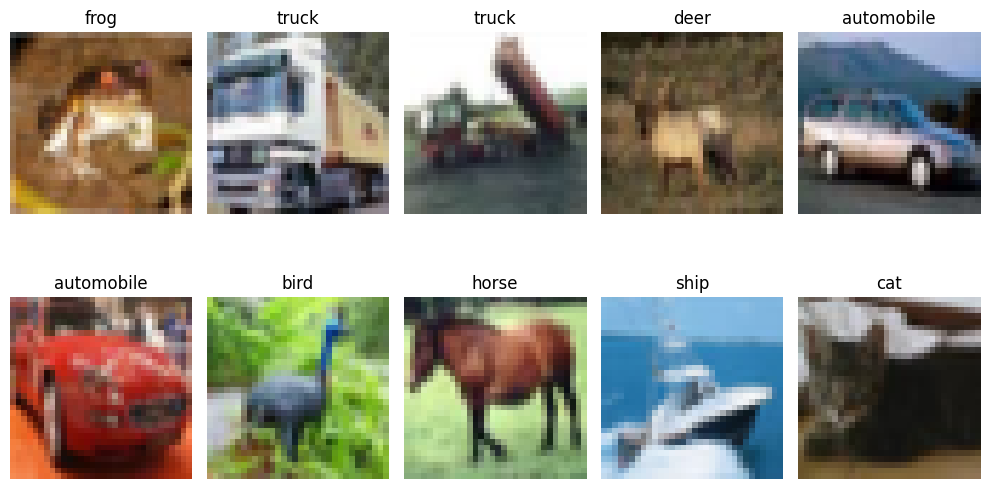

In [1]:
# EXPT NO: 3
# IMPLEMENTATION OF CONVOLUTIONAL NEURAL NETWORKS (CNNs)
# FOR IMAGE CLASSIFICATION
# Student Roll No: 24BAD103

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Display TensorFlow version
print("TensorFlow Version:", tf.__version__)

# TASK A: DATASET PREPARATION

# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Class names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# Display dataset shapes
print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", X_test.shape)
print("Testing labels:", y_test.shape)

# Normalize pixel values from [0, 255] to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Remove extra dimension from labels
y_train = y_train.flatten()
y_test = y_test.flatten()

# Split training data into training and validation sets
validation_size = 5000

X_val = X_train[-validation_size:]
y_val = y_train[-validation_size:]

X_train = X_train[:-validation_size]
y_train = y_train[:-validation_size]

# Display final dataset sizes
print("\nAfter preprocessing:")
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set:", X_test.shape)

# DISPLAY SAMPLE IMAGES

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# TASK B: CNN MODEL IMPLEMENTATION
# Student Roll No: 24BAD103

import tensorflow as tf
from tensorflow.keras import models, layers

# Create CNN model
model = models.Sequential([

    # Convolution Layer 1 + ReLU
    layers.Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(32, 32, 3)
    ),

    # Max Pooling Layer 1
    layers.MaxPooling2D((2, 2)),

    # Convolution Layer 2 + ReLU
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    # Max Pooling Layer 2
    layers.MaxPooling2D((2, 2)),

    # Convolution Layer 3 + ReLU
    layers.Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    # Flatten feature maps
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(64, activation='relu'),

    # Softmax Output Layer - 10 CIFAR-10 classes
    layers.Dense(10, activation='softmax')
])

# Display CNN architecture
model.summary()

# COMPILE THE MODEL

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("\nCNN model compiled successfully.")

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 91ms/step - accuracy: 0.4206 - loss: 1.5838 - val_accuracy: 0.5262 - val_loss: 1.3023
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.5640 - loss: 1.2243 - val_accuracy: 0.6242 - val_loss: 1.0835
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 63s 89ms/step - accuracy: 0.6265 - loss: 1.0555 - val_accuracy: 0.6580 - val_loss: 1.0132
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 87ms/step - accuracy: 0.6733 - loss: 0.9405 - val_accuracy: 0.6782 - val_loss: 0.9315
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.6975 - loss: 0.8618 - val_accuracy: 0.6870 - val_loss: 0.9056
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 86ms/step - accuracy: 0.7188 - loss: 0.7989 - val_accuracy: 0.6984 - val_loss: 0.8734
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 86ms/step - accuracy: 0.7388 - loss: 0.7424 - val_accuracy: 0.7208 - val_loss: 0.8110
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 86ms/step - accuracy: 0.7556 - loss: 0.6968 - 

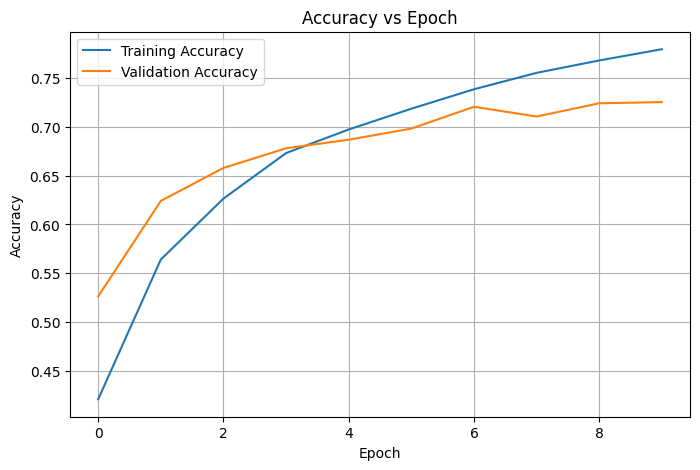

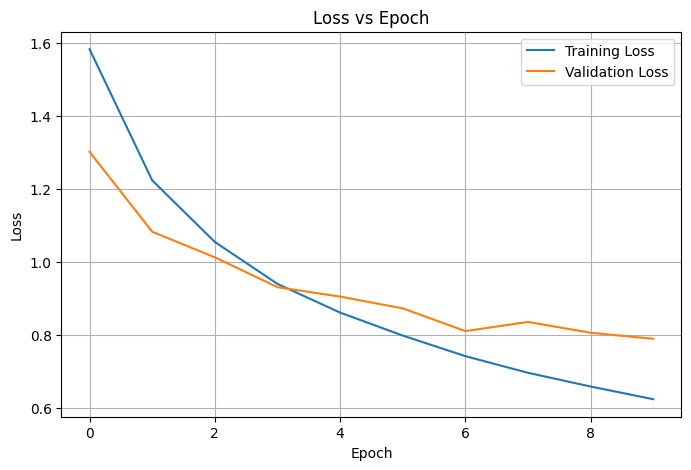

In [3]:
# TASK C: MODEL TRAINING AND EVALUATION
# Student Roll No: 24BAD103
# Train the CNN model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)
# DISPLAY TRAINING RESULTS
print("\nTraining Results:")
for epoch in range(10):
    print(
        f"Epoch {epoch + 1}: "
        f"Training Accuracy = {history.history['accuracy'][epoch]:.4f}, "
        f"Validation Accuracy = {history.history['val_accuracy'][epoch]:.4f}, "
        f"Training Loss = {history.history['loss'][epoch]:.4f}, "
        f"Validation Loss = {history.history['val_loss'][epoch]:.4f}"
    )
# TEST THE MODEL

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("\nFinal Test Results:")
print(f"Testing Loss     : {test_loss:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy * 100:.2f}%")

# ACCURACY VS EPOCH
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# LOSS VS EPOCH

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)
plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

PERFORMANCE ANALYSIS
--------------------
Test Loss     : 0.8475
Test Accuracy : 0.7092
Classification Accuracy: 70.92%


<Figure size 900x900 with 0 Axes>

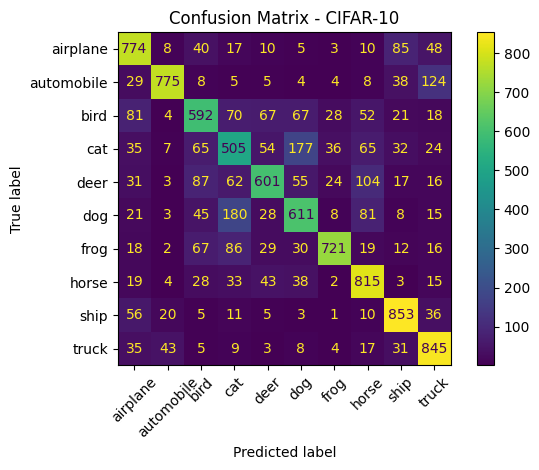

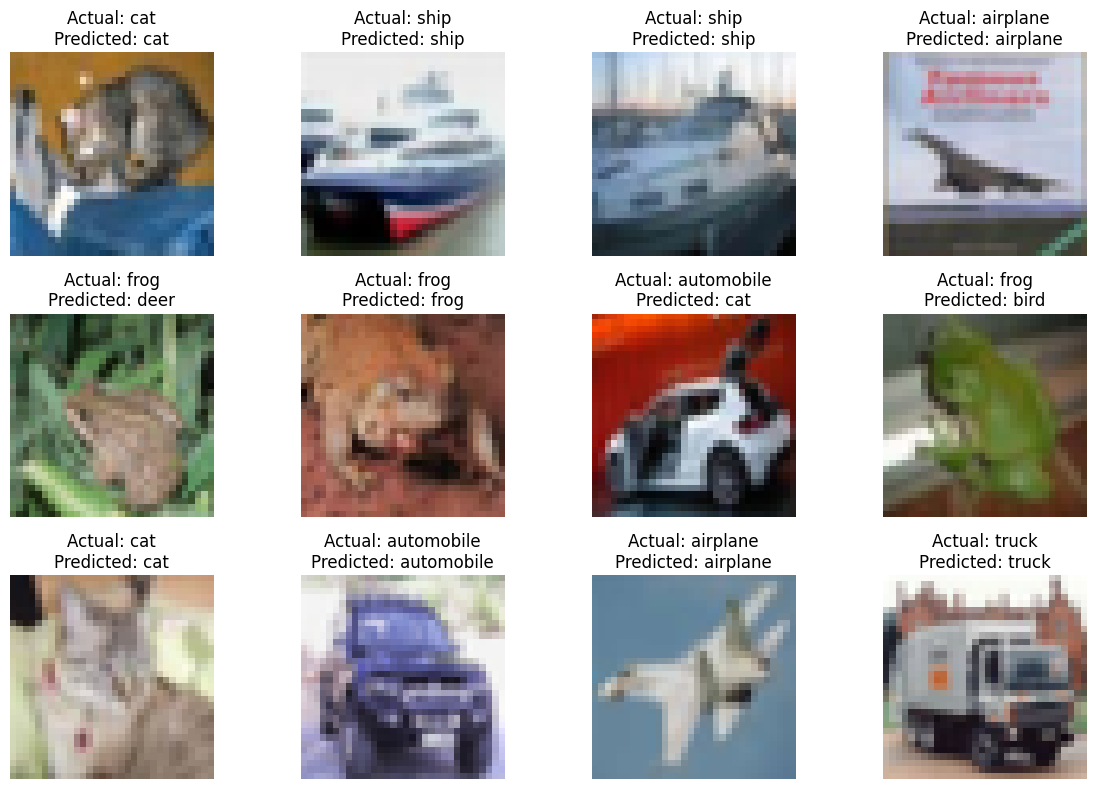


Number of misclassified images: 2908


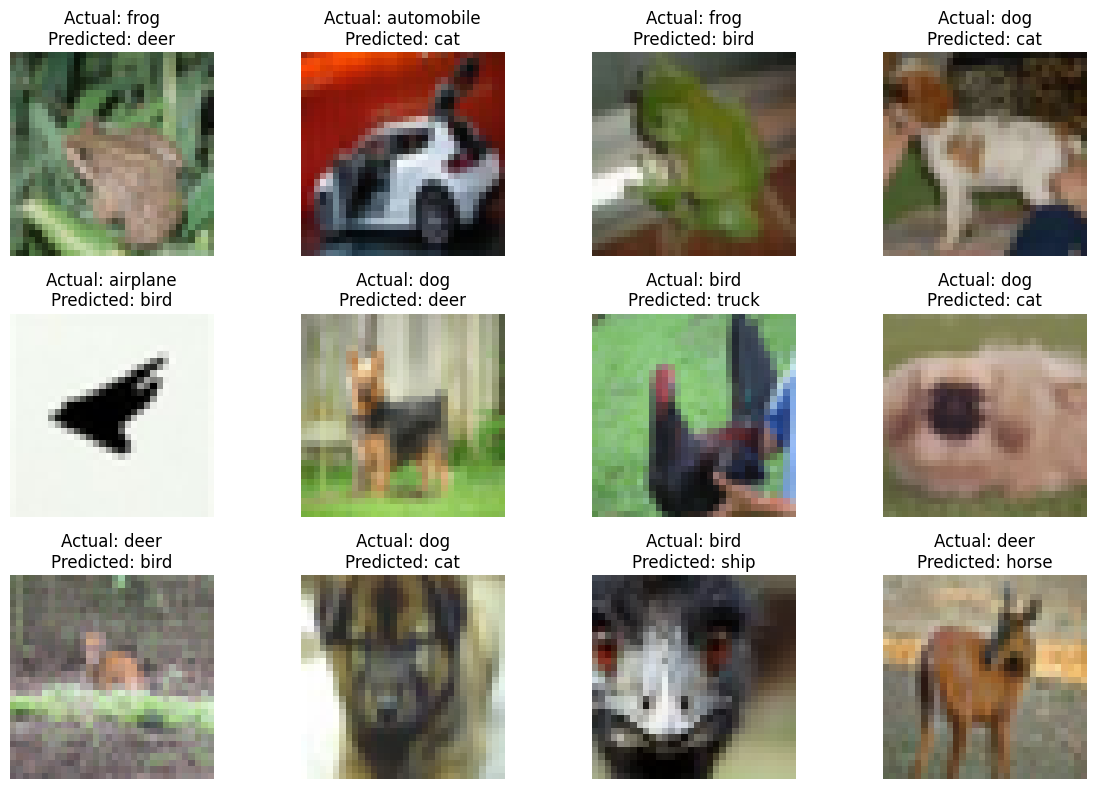

In [4]:
# TASK D: PERFORMANCE ANALYSIS
# Student Roll No: 24BAD103
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. CLASSIFICATION ACCURACY

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("PERFORMANCE ANALYSIS")
print("--------------------")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Classification Accuracy: {test_accuracy * 100:.2f}%")

# 2. GENERATE PREDICTIONS

predictions = model.predict(X_test, verbose=0)

predicted_labels = np.argmax(predictions, axis=1)

# 3. CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    predicted_labels
)

plt.figure(figsize=(9, 9))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    values_format='d'
)

plt.title("Confusion Matrix - CIFAR-10")
plt.tight_layout()
plt.show()

# 4. SAMPLE PREDICTIONS

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[i])

    actual = class_names[y_test[i]]
    predicted = class_names[predicted_labels[i]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()

# 5. FIND MISCLASSIFIED IMAGES

misclassified_indices = np.where(
    predicted_labels != y_test
)[0]

print("\nNumber of misclassified images:",
      len(misclassified_indices))

# 6. DISPLAY MISCLASSIFIED IMAGES

plt.figure(figsize=(12, 8))

num_images = min(12, len(misclassified_indices))

for i in range(num_images):

    index = misclassified_indices[i]

    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[index])

    actual = class_names[y_test[index]]
    predicted = class_names[predicted_labels[index]]

    plt.title(
        f"Actual: {actual}\nPredicted: {predicted}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()